In [3]:
import os
from dotenv import load_dotenv


load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')
os.environ['LANGSMITH_API_KEY'] = os.getenv('langsmit_api_key')

In [5]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [13]:
# LLM
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model='openai/gpt-oss-120b')

In [9]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [10]:
def chatbot(state: State):
    return {'messages': [llm_groq.invoke(state['messages'])]}

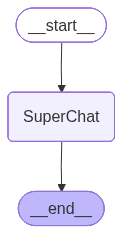

In [14]:
graph = StateGraph(State)

# Nodes
graph.add_node('SuperChat', chatbot)

# Edges
graph.add_edge(START, 'SuperChat')
graph.add_edge('SuperChat', END)

# Compile
graph_builder = graph.compile()

# Display
from IPython.display import Image, display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [15]:
# Result
graph_builder.invoke({'messages': 'Hey, My name is Aaron and I am a Gen AI developer'})

{'messages': [HumanMessage(content='Hey, My name is Aaron and I am a Gen AI developer', additional_kwargs={}, response_metadata={}, id='94ef830c-c8fe-47a6-a611-77ca9710e1f8'),
  AIMessage(content='Hi Aaron! Great to meet you. 🚀\n\nAs a Gen\u202fAI developer, you’re probably working on some exciting projects. How can I help you today? Whether it’s brainstorming ideas, troubleshooting code, exploring model architectures, or anything else, just let me know!', additional_kwargs={'reasoning_content': 'The user says: "Hey, My name is Aaron and I am a Gen AI developer". Likely they are introducing themselves. The assistant should respond politely, maybe ask how can help, etc. There\'s no disallowed content. Just respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 84, 'total_tokens': 200, 'completion_time': 0.248779947, 'completion_tokens_details': {'reasoning_tokens': 51}, 'prompt_time': 0.00379858, 'prompt_tokens_details': None, 'queue_time': 0.